# Analisis Spasio-Temporal Deforestasi & Kebakaran Hutan Provinsi Jambi (2020-2024)

Notebook ini melakukan analisis dan visualisasi data hasil ekstraksi GEE sesuai metodologi di TASK.md (Tahap 1-4).
Data sumber: `Task_Stats_Deforestasi_Drive.csv` dan `Task_Stats_Burn_Drive.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
df_defor = pd.read_csv('data/Task_Stats_Deforestasi_Drive.csv')
df_burn = pd.read_csv('data/Task_Stats_Burn_Drive.csv')
df_defor['Year'] = df_defor['Year_Transition'].str[:4].astype(int)
df_burn['Year'] = df_burn['Year_Transition'].str[:4].astype(int)
df_defor

,system:index,GFW_Loss,NDVI_Defor,Overlap,Year_Transition,.geo,Year
0,0,77205.816811,65357.970348,10263.239700,2020-2021,"{""type"":""MultiPoint"",""coordinates"":[]}",2020
1,1,79485.816381,26125.653086,4778.417456,2021-2022,"{""type"":""MultiPoint"",""coordinates"":[]}",2021
2,2,102788.695375,103375.950157,19550.411973,2022-2023,"{""type"":""MultiPoint"",""coordinates"":[]}",2022
3,3,99062.957126,78642.356708,13573.702335,2023-2024,"{""type"":""MultiPoint"",""coordinates"":[]}",2023
4,4,79933.316289,48631.446142,8023.002864,2024-2025,"{""type"":""MultiPoint"",""coordinates"":[]}",2024


In [4]:
print('=== DEFORESTASI DATA ===')
display(df_defor)
print()
print('=== KEBAKARAN DATA ===')
display(df_burn)

=== DEFORESTASI DATA ===


,system:index,GFW_Loss,NDVI_Defor,Overlap,Year_Transition,.geo,Year
0,0,77205.816811,65357.970348,10263.239700,2020-2021,"{""type"":""MultiPoint"",""coordinates"":[]}",2020
1,1,79485.816381,26125.653086,4778.417456,2021-2022,"{""type"":""MultiPoint"",""coordinates"":[]}",2021
2,2,102788.695375,103375.950157,19550.411973,2022-2023,"{""type"":""MultiPoint"",""coordinates"":[]}",2022
3,3,99062.957126,78642.356708,13573.702335,2023-2024,"{""type"":""MultiPoint"",""coordinates"":[]}",2023
4,4,79933.316289,48631.446142,8023.002864,2024-2025,"{""type"":""MultiPoint"",""coordinates"":[]}",2024



=== KEBAKARAN DATA ===


,system:index,Burn_Overlap,MCD64_Area,Year_Transition,dNBR_Area,.geo,Year
0,0,148.964409,694.846445,2020-2021,38789.323556,"{""type"":""MultiPoint"",""coordinates"":[]}",2020
1,1,0.000000,794.114447,2021-2022,24287.624482,"{""type"":""MultiPoint"",""coordinates"":[]}",2021
2,2,422.038098,3993.204810,2022-2023,61692.150393,"{""type"":""MultiPoint"",""coordinates"":[]}",2022
3,3,1117.169400,7444.006929,2023-2024,68902.525179,"{""type"":""MultiPoint"",""coordinates"":[]}",2023
4,4,546.165370,4468.294044,2024-2025,37935.930860,"{""type"":""MultiPoint"",""coordinates"":[]}",2024


In [5]:
print("AKU NGECEK MCP GAYSSS")

AKU NGECEK MCP GAYSSS


## 1. Tren Deforestasi Tahunan (GFW vs NDVI-based)

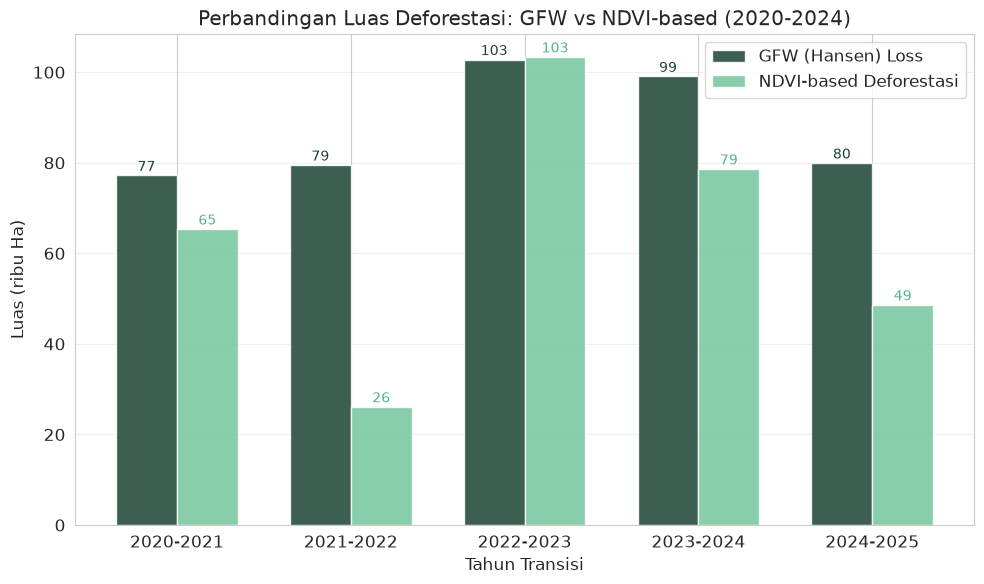

In [13]:
print('=== PERBANDINGAN LUAS DEFORESTASI TAHUNAN (Ha) ===')
tabel = pd.DataFrame({
    'Tahun': df_defor['Year_Transition'],
    'GFW_Loss_Ha': df_defor['GFW_Loss'].values,
    'NDVI_Defor_Ha': df_defor['NDVI_Defor'].values,
    'Selisih_Ha': (df_defor['GFW_Loss'] - df_defor['NDVI_Defor']).values,
    'Selisih_%': ((df_defor['GFW_Loss'] - df_defor['NDVI_Defor']) / df_defor['GFW_Loss'] * 100).values.round(1)
})
display(tabel.style.format({'GFW_Loss_Ha': '{:,.1f}', 'NDVI_Defor_Ha': '{:,.1f}', 'Selisih_Ha': '{:,.1f}'}).hide(axis='index'))
print()
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_defor))
width = 0.35
ax.bar(x - width/2, df_defor['GFW_Loss'].values/1000, width, label='GFW (Hansen) Loss', color='#1b4332', alpha=0.85)
ax.bar(x + width/2, df_defor['NDVI_Defor'].values/1000, width, label='NDVI-based Deforestasi', color='#74c69d', alpha=0.85)
ax.set_xlabel('Tahun Transisi')
ax.set_ylabel('Luas (ribu Ha)')
ax.set_title('Perbandingan Luas Deforestasi: GFW vs NDVI-based (2020-2024)')
ax.set_xticks(x)
ax.set_xticklabels(df_defor['Year_Transition'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_defor['GFW_Loss'].values/1000):
    ax.text(i - width/2, v + 1, f'{v:.0f}', ha='center', fontsize=10, color='#1b4332')
for i, v in enumerate(df_defor['NDVI_Defor'].values/1000):
    ax.text(i + width/2, v + 1, f'{v:.0f}', ha='center', fontsize=10, color='#52b788')
fig.tight_layout()
plt.show()

## 2. Overlap Deforestasi (GFW vs NDVI) - Validasi Spasial

In [14]:
print('=== OVERLAP GFW vs NDVI ===')
tabel = pd.DataFrame({
    'Tahun': df_defor['Year_Transition'],
    'Overlap_Ha': df_defor['Overlap'].values,
    'Pct_vs_GFW': (df_defor['Overlap'] / df_defor['GFW_Loss'] * 100).values.round(1),
    'Pct_vs_NDVI': (df_defor['Overlap'] / df_defor['NDVI_Defor'] * 100).values.round(1)
})
display(tabel.style.format({'Overlap_Ha': '{:,.1f}'}).hide(axis='index'))
print(f'\nTotal overlap 2020-2024: {df_defor["Overlap"].sum():,.0f} Ha')
print(f'Rata-rata kesesuaian GFW-NDVI: {df_defor["Overlap"].sum()/df_defor["GFW_Loss"].sum()*100:.1f}% dari GFW')
print()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_defor['Year'].values, df_defor['Overlap'].values/1000, color='#e07a5f', alpha=0.8, label='Overlap (GFW ∩ NDVI)')
ax.plot(df_defor['Year'].values, df_defor['Overlap'].values/df_defor['GFW_Loss'].values*100, 'o-', color='#3d405b', linewidth=2, markersize=8, label='Overlap / GFW (%)')
ax.set_xlabel('Tahun Transisi')
ax.set_ylabel('Luas Overlap (ribu Ha)', color='#e07a5f')
ax.tick_params(axis='y', labelcolor='#e07a5f')
ax.set_xticks(df_defor['Year'].values)
ax.set_xticklabels(df_defor['Year_Transition'])
ax.set_title('Validasi Spasial: Overlap GFW vs NDVI-based Deforestasi')
ax.legend(loc='upper left')
ax2 = ax.twinx()
ax2.set_ylabel('Persentase Overlap (%)', color='#3d405b')
ax2.tick_params(axis='y', labelcolor='#3d405b')
ax2.set_ylim(0, 30)
for i, v in enumerate(df_defor['Overlap'].values/1000):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10, color='#e07a5f')
for i, v in enumerate(df_defor['Overlap'].values/df_defor['GFW_Loss'].values*100):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, color='#3d405b')
fig.subplots_adjust(right=0.85)
plt.show()

## 3. Tren Luas Kebakaran (dNBR vs MODIS MCD64A1)

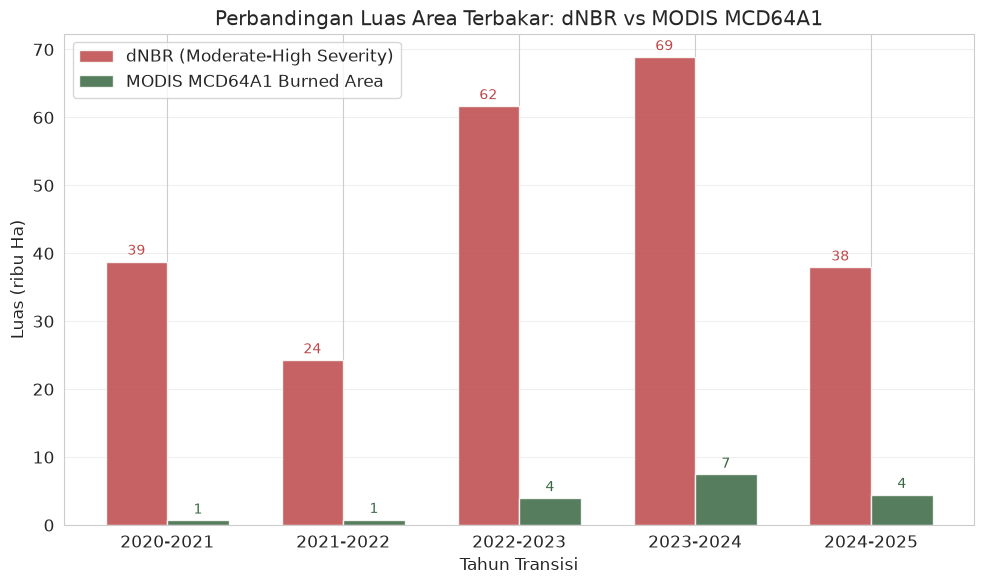

In [15]:
print('=== PERBANDINGAN LUAS AREA TERBAKAR TAHUNAN (Ha) ===')
tabel = pd.DataFrame({
    'Tahun': df_burn['Year_Transition'],
    'dNBR_Area_Ha': df_burn['dNBR_Area'].values,
    'MCD64_Area_Ha': df_burn['MCD64_Area'].values,
    'Ratio_dNBR_MCD64': (df_burn['dNBR_Area'] / df_burn['MCD64_Area']).values.round(2)
})
display(tabel.style.format({'dNBR_Area_Ha': '{:,.1f}', 'MCD64_Area_Ha': '{:,.1f}'}).hide(axis='index'))
print(f'\ndNBR total: {df_burn["dNBR_Area"].sum():,.0f} Ha')
print(f'MODIS MCD64A1 total: {df_burn["MCD64_Area"].sum():,.0f} Ha')
print(f'Rasio dNBR/MODIS: {df_burn["dNBR_Area"].sum()/df_burn["MCD64_Area"].sum():.2f}x')
print()
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_burn))
width = 0.35
ax.bar(x - width/2, df_burn['dNBR_Area'].values/1000, width, label='dNBR (Moderate-High Severity)', color='#bc4749', alpha=0.85)
ax.bar(x + width/2, df_burn['MCD64_Area'].values/1000, width, label='MODIS MCD64A1 Burned Area', color='#386641', alpha=0.85)
ax.set_xlabel('Tahun Transisi')
ax.set_ylabel('Luas (ribu Ha)')
ax.set_title('Perbandingan Luas Area Terbakar: dNBR vs MODIS MCD64A1')
ax.set_xticks(x)
ax.set_xticklabels(df_burn['Year_Transition'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_burn['dNBR_Area'].values/1000):
    ax.text(i - width/2, v + 1, f'{v:.0f}', ha='center', fontsize=10, color='#bc4749')
for i, v in enumerate(df_burn['MCD64_Area'].values/1000):
    ax.text(i + width/2, v + 1, f'{v:.0f}', ha='center', fontsize=10, color='#386641')
fig.tight_layout()
plt.show()

## 4. Deforestasi Terkait Kebakaran (Burn Overlap)

In [16]:
print('=== DEFORESTASI TERKAIT KEBAKARAN (Ha) ===')
tabel = pd.DataFrame({
    'Tahun': df_burn['Year_Transition'],
    'Burn_Overlap_Ha': df_burn['Burn_Overlap'].values,
    'Pct_vs_dNBR': (df_burn['Burn_Overlap'] / df_burn['dNBR_Area'] * 100).values.round(2),
    'Pct_vs_GFW': (df_burn['Burn_Overlap'] / df_defor['GFW_Loss'] * 100).values.round(2)
})
display(tabel.style.format({'Burn_Overlap_Ha': '{:,.2f}'}).hide(axis='index'))
print(f'\nTotal overlap deforestasi-kebakaran: {df_burn["Burn_Overlap"].sum():,.0f} Ha')
print(f'Persentase dari total deforestasi GFW: {df_burn["Burn_Overlap"].sum()/df_defor["GFW_Loss"].sum()*100:.2f}%')
print(f'Persentase dari total dNBR: {df_burn["Burn_Overlap"].sum()/df_burn["dNBR_Area"].sum()*100:.2f}%')
print()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_burn['Year'].values, df_burn['Burn_Overlap'].values/1000, color='#2a9d8f', alpha=0.8)
ax.plot(df_burn['Year'].values, df_burn['Burn_Overlap'].values/df_burn['dNBR_Area'].values*100, 'o-', color='#264653', linewidth=2, markersize=8, label='Burn Overlap / dNBR (%)')
ax.set_xlabel('Tahun Transisi')
ax.set_ylabel('Luas Overlap (ribu Ha)', color='#2a9d8f')
ax.tick_params(axis='y', labelcolor='#2a9d8f')
ax.set_xticks(df_burn['Year'].values)
ax.set_xticklabels(df_burn['Year_Transition'])
ax.set_title('Deforestasi yang Berhimpitan dengan Area Kebakaran (dNBR Moderate-High)')
ax.legend(loc='upper left')
ax2 = ax.twinx()
ax2.set_ylabel('Persentase Overlap (%)', color='#264653')
ax2.tick_params(axis='y', labelcolor='#264653')
ax2.set_ylim(0, 5)
for i, v in enumerate(df_burn['Burn_Overlap'].values/1000):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, color='#2a9d8f')
for i, v in enumerate(df_burn['Burn_Overlap'].values/df_burn['dNBR_Area'].values*100):
    ax2.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10, color='#264653')
fig.subplots_adjust(right=0.85)
plt.show()

## 5. Ringkasan Statistik & Interpretasi

In [17]:
summary = pd.DataFrame({
    'Tahun': df_defor['Year_Transition'],
    'GFW_Loss_Ha': df_defor['GFW_Loss'].round(1),
    'NDVI_Defor_Ha': df_defor['NDVI_Defor'].round(1),
    'Overlap_GFW_NDVI_Ha': df_defor['Overlap'].round(1),
    'Overlap_Pct_GFW': (df_defor['Overlap']/df_defor['GFW_Loss']*100).round(2),
    'dNBR_Area_Ha': df_burn['dNBR_Area'].round(1),
    'MCD64_Area_Ha': df_burn['MCD64_Area'].round(1),
    'Burn_Overlap_Ha': df_burn['Burn_Overlap'].round(1),
    'Burn_Overlap_Pct_dNBR': (df_burn['Burn_Overlap']/df_burn['dNBR_Area']*100).round(2)
})
summary

,Tahun,GFW_Loss_Ha,NDVI_Defor_Ha,Overlap_GFW_NDVI_Ha,Overlap_Pct_GFW,dNBR_Area_Ha,MCD64_Area_Ha,Burn_Overlap_Ha,Burn_Overlap_Pct_dNBR
0,2020-2021,77205.8,65358.0,10263.2,13.29,38789.3,694.8,149.0,0.38
1,2021-2022,79485.8,26125.7,4778.4,6.01,24287.6,794.1,0.0,0.00
2,2022-2023,102788.7,103376.0,19550.4,19.02,61692.2,3993.2,422.0,0.68
3,2023-2024,99063.0,78642.4,13573.7,13.70,68902.5,7444.0,1117.2,1.62
4,2024-2025,79933.3,48631.4,8023.0,10.04,37935.9,4468.3,546.2,1.44


## 6. Analisis Tren & Kesimpulan Kunci

In [ ]:
print('=== RINGKASAN TEMUAN UTAMA ===')
print()
print('1. DEFORESTASI TOTAL:')
print(f'   - GFW Total 2020-2024: {df_defor["GFW_Loss"].sum():,.1f} Ha')
print(f'   - NDVI-based Total 2020-2024: {df_defor["NDVI_Defor"].sum():,.1f} Ha')
print(f'   - Overlap Total: {df_defor["Overlap"].sum():,.1f} Ha ({df_defor["Overlap"].sum()/df_defor["GFW_Loss"].sum()*100:.1f}% dari GFW)')
print()
print('2. KEBAKARAN (dNBR Moderate-High):')
print(f'   - Total dNBR Area: {df_burn["dNBR_Area"].sum():,.1f} Ha')
print(f'   - Total MODIS MCD64A1: {df_burn["MCD64_Area"].sum():,.1f} Ha')
print(f'   - Ratio dNBR/MODIS: {df_burn["dNBR_Area"].sum()/df_burn["MCD64_Area"].sum():.2f}x')
print()
print('3. DEFORESTASI TERKAIT KEBAKARAN:')
print(f'   - Total Burn Overlap: {df_burn["Burn_Overlap"].sum():,.1f} Ha')
print(f'   - Rata-rata persentase deforestasi akibat kebakaran: {df_burn["Burn_Overlap"].sum()/df_defor["GFW_Loss"].sum()*100:.2f}% dari total deforestasi GFW')
print(f'   - Persentase dari area dNBR: {df_burn["Burn_Overlap"].sum()/df_burn["dNBR_Area"].sum()*100:.2f}%')
print()
print('4. TREN TAHUNAN:')
peak_defor = df_defor.loc[df_defor['GFW_Loss'].idxmax()]
peak_burn = df_burn.loc[df_burn['dNBR_Area'].idxmax()]
print(f'   - Puncak deforestasi: {peak_defor["Year_Transition"]} ({peak_defor["GFW_Loss"]:,.0f} Ha)')
print(f'   - Puncak kebakaran dNBR: {peak_burn["Year_Transition"]} ({peak_burn["dNBR_Area"]:,.0f} Ha)')
print()
print('5. INTERPRETASI METODE PEMBUKAAN LAHAN:')
burn_pct = df_burn['Burn_Overlap'].sum()/df_defor['GFW_Loss'].sum()*100
if burn_pct < 10:
    print(f'   - Hanya {burn_pct:.1f}% deforestasi terkait kebakaran -> Dominan pembersihan mekanis/non-bakar')
elif burn_pct < 30:
    print(f'   - {burn_pct:.1f}% deforestasi terkait kebakaran -> Campuran pembakaran tradisional & mekanis')
else:
    print(f'   - {burn_pct:.1f}% deforestasi terkait kebakaran -> Dominan pembakaran tradisional')